# Fine tuning pretrained BERT models to predict reasons for Cannabis Use in Lupus Patients EHR

based on Nathan Le's code, extending to different fine-tuning strategies

*yiyu wang 2025/02*

In [1]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

import random, numpy as np, torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)



In [2]:
import transformers
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
import torch
from torch.optim import AdamW
import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap
import math
from sklearn.model_selection import StratifiedKFold
from typing import Dict, List
from sklearn.metrics import roc_auc_score

from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

from tqdm import tqdm
import os

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

HAPPY_COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]

sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))

rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device


2026-01-06 09:17:20.540902: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-06 09:17:20.562915: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-06 09:17:20.962250: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


device(type='cuda', index=0)

In [3]:
df_test = pd.read_csv("data/set-validation_task-status_label-4_sample-10_desc-stratified.csv")
# rename to label
df_test = df_test[["Snippets", "Label"]]
df_test = df_test.rename(columns={"Label": "label", "Snippets": "text"})
df_test['label'] = df_test['label']-1
print(df_test.columns)
class_label_names = ['Not A True Mention', 'Denial of Use', 'Positive Past Use', 'Positive Current Use']

Index(['text', 'label'], dtype='object')


Text(0.5, 0, 'label')

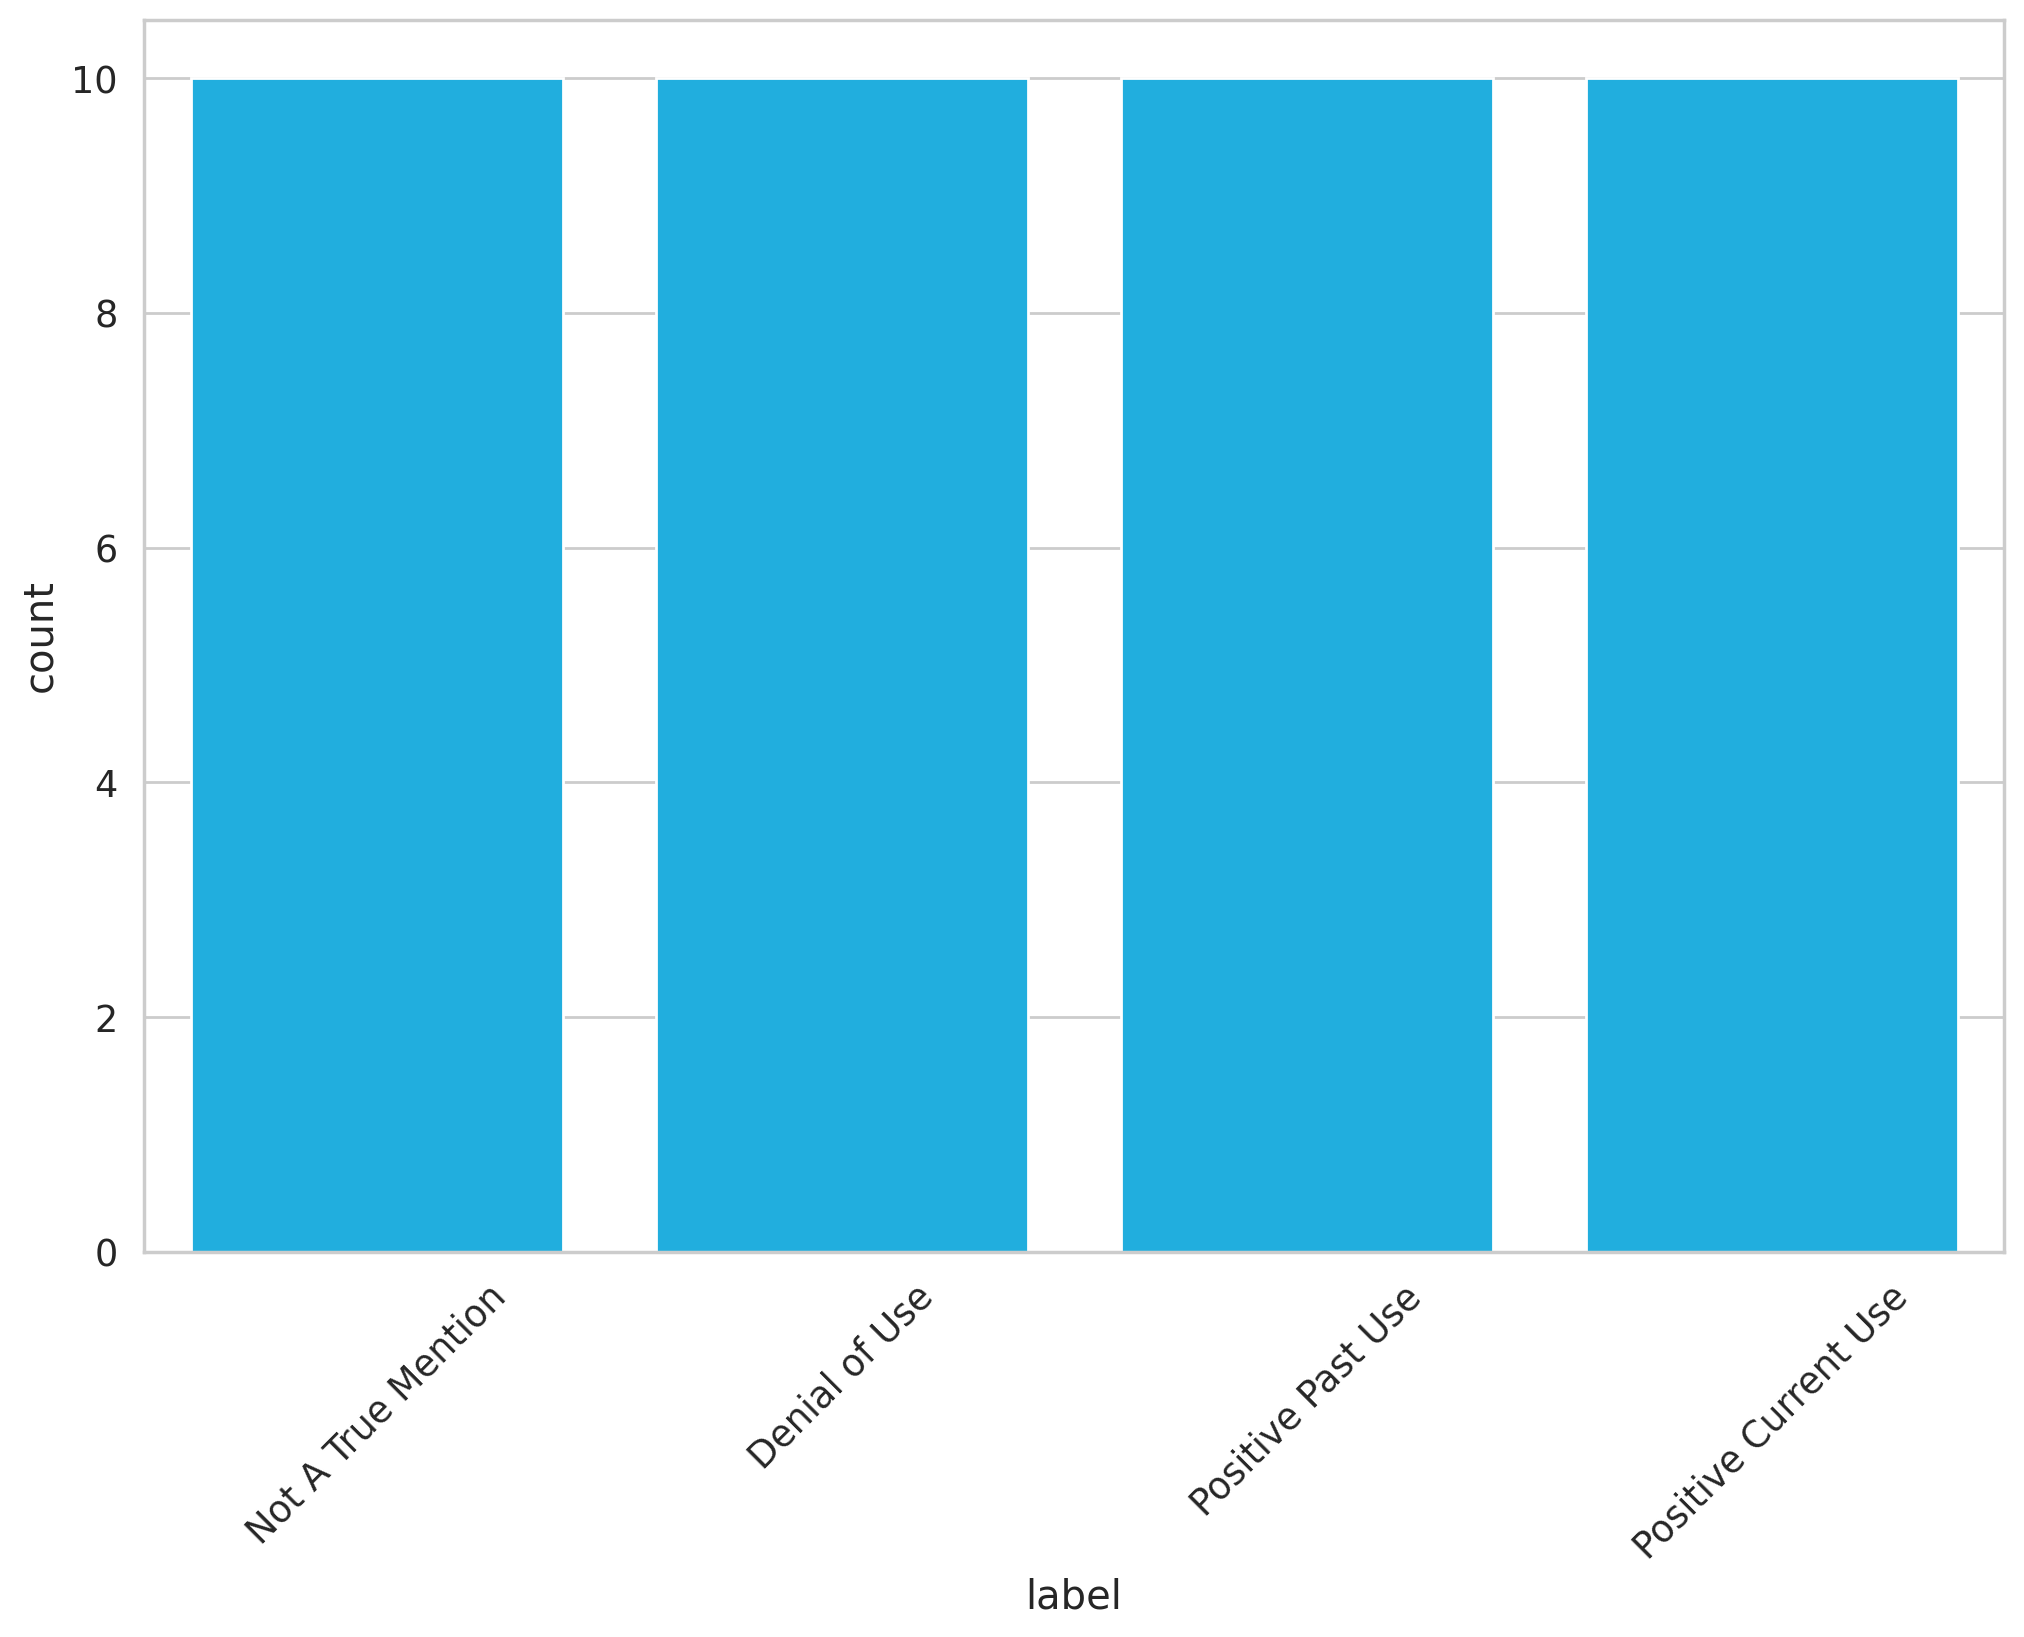

In [4]:
# distribution of the four class in sentiment
sns.barplot(x=df_test.label.value_counts().index, y=df_test.label.value_counts())
plt.xticks(ticks=range(len(class_label_names)), labels=class_label_names, rotation=45)
plt.xlabel('label')

In [5]:
from transformers import AutoTokenizer, AutoModel
# PRE_TRAINED_MODEL_NAME="roberta-large-mnli"
tokenizer = AutoTokenizer.from_pretrained('LLMs/gatortron-base', local_files_only=True)


In [6]:
tokenizer.sep_token, tokenizer.sep_token_id


('[SEP]', 102)

In [7]:
tokenizer.cls_token, tokenizer.cls_token_id


('[CLS]', 101)

In [8]:
tokenizer.pad_token, tokenizer.pad_token_id


('[PAD]', 0)

In [9]:
tokenizer.unk_token, tokenizer.unk_token_id


('[UNK]', 100)

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


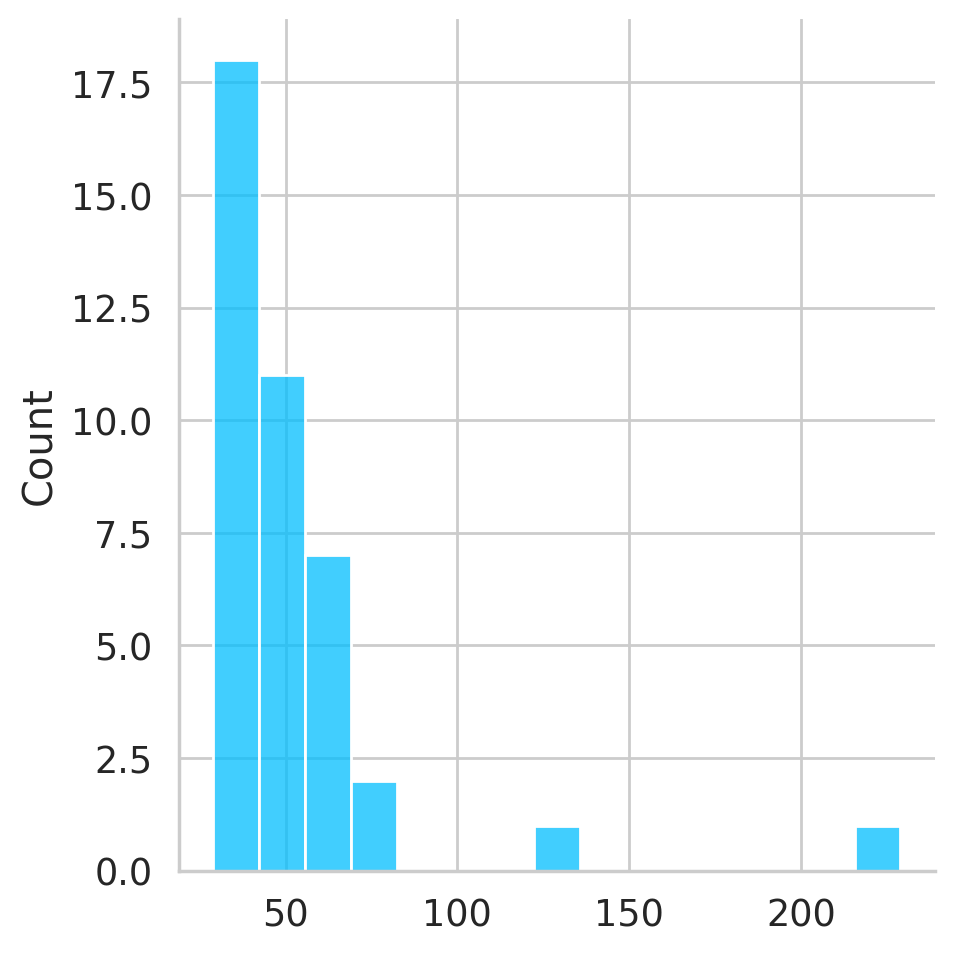

In [10]:
token_lens=[]
for txt in df_test.text:
  tokens=tokenizer.encode(txt,max_length=512)
  token_lens.append(len(tokens))
sns.displot(token_lens)

In [11]:
class CannabisClassData(Dataset):
  def __init__(self, text, label, tokenizer, max_len):
    self.text=text
    self.label=label
    self.tokenizer=tokenizer
    self.max_len=max_len
    
  def __len__(self):
    return len(self.text)
  
  def __getitem__(self,item):
    text= str(self.text[item])
    label=self.label[item]
    encoding=self.tokenizer.encode_plus(
    text,
    max_length=self.max_len,
    add_special_tokens=True,
    # pad_to_max_length=True,
    truncation =True,
    return_attention_mask=True,
    return_token_type_ids=False,
    return_tensors='pt'
    )
    return{
        'text':text,
        'input_ids': encoding['input_ids'].flatten(),
        'attention_mask': encoding['attention_mask'].flatten(),
        'label':torch.tensor(label,dtype=torch.long)
    }

    


In [12]:
from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
    input_ids = [b["input_ids"] for b in batch]
    attention_mask = [b["attention_mask"] for b in batch]
    labels = [b["label"] for b in batch]
    

    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
    labels = torch.tensor(labels)

    return {"input_ids": input_ids, "attention_mask": attention_mask, "label": labels}


def create_data_loader(df, tokenizer, max_len, batch_size, collate_fn=collate_fn):
  ds = CannabisClassData(
    text=df.text.to_numpy(),
    label=df.label.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
  )
  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=0,
    collate_fn=collate_fn
  )
     

In [13]:
class CannabisClassifier(nn.Module):
  def __init__(self,PRE_TRAINED_MODEL_NAME,n_classes, dropout_rate=0.3):
    super(CannabisClassifier,self).__init__()
    self.bert=AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME, local_files_only=True)
    self.drop=nn.Dropout(p=dropout_rate)
    self.out=nn.Linear(self.bert.config.hidden_size,n_classes)
    self.softmax=nn.Softmax(dim=1)
  def forward(self,input_ids,attention_mask):
    _,pooled_output=self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask,
      return_dict=False
    )
    output=self.drop(pooled_output)
    output=self.out(output)
    #return self.softmax(output)
    return nn.LogSoftmax(dim=1)(output)

In [14]:
class CannabisClassifierFrozenBackbone(nn.Module):
    def __init__(self, PRE_TRAINED_MODEL_NAME, n_classes, dropout_rate=0.1):
        super(CannabisClassifierFrozenBackbone, self).__init__()
        self.bert = AutoModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
        for param in self.bert.parameters():
            param.requires_grad = False
        hidden_size = self.bert.config.hidden_size
        self.drop=nn.Dropout(p=dropout_rate)
        self.out = nn.Linear(hidden_size, n_classes)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, input_ids, attention_mask):
        _, pooled_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=False
        )
        output=self.drop(pooled_output)
        output=self.out(output)
        #return self.softmax(output)
        return nn.LogSoftmax(dim=1)(output)

In [15]:
def train_epoch(
    model,
    data_loader,
    loss_fn,
    optimizer,
    device,
    scheduler,
):
    model=model.train()
    model.to(device)
    losses=[]
    running_loss=0.0

    for d in data_loader:
      input_ids=d['input_ids'].to(device)
      attention_mask=d['attention_mask'].to(device)
      label=d['label'].to(device)


      outputs=model(
          input_ids=input_ids,
          attention_mask=attention_mask
      )

      preds=torch.max(outputs,dim=1)
      loss=loss_fn(outputs,label)

      #correct_predictions += torch.sum(torch.eq(preds, label))
      # correct_predictions +=torch.sum(torch.eq(torch.argmax(outputs,dim=1).cpu(), label.cpu()))
      losses.append(loss.item())

      loss.backward()
      nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
      optimizer.step()
      scheduler.step()
      optimizer.zero_grad()
      running_loss += loss.item() / len(data_loader)

    return running_loss

In [16]:
import torch

def eval_model(model, data_loader, loss_fn, device):
    model.eval()  # set model to evaluation mode
    model.to(device)
    
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            labels = d["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            # predictions = argmax over class dimension
            preds = torch.argmax(outputs, dim=1)
            correct_predictions += torch.sum(preds == labels).item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions / total_samples

    return avg_loss, accuracy


In [17]:
def get_predictions(model, data_loader):
  model = model.eval()
  model.to(device)
  
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      label = d["label"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      probs = F.softmax(outputs, dim=1)

      predictions.extend(preds)
      prediction_probs.extend(probs)
      real_values.extend(label)

  predictions = torch.stack(predictions).cpu()
  prediction_probs = torch.stack(prediction_probs).cpu()
  real_values = torch.stack(real_values).cpu()

  return predictions, prediction_probs, real_values

Text(0.5, 0, 'sentiment')

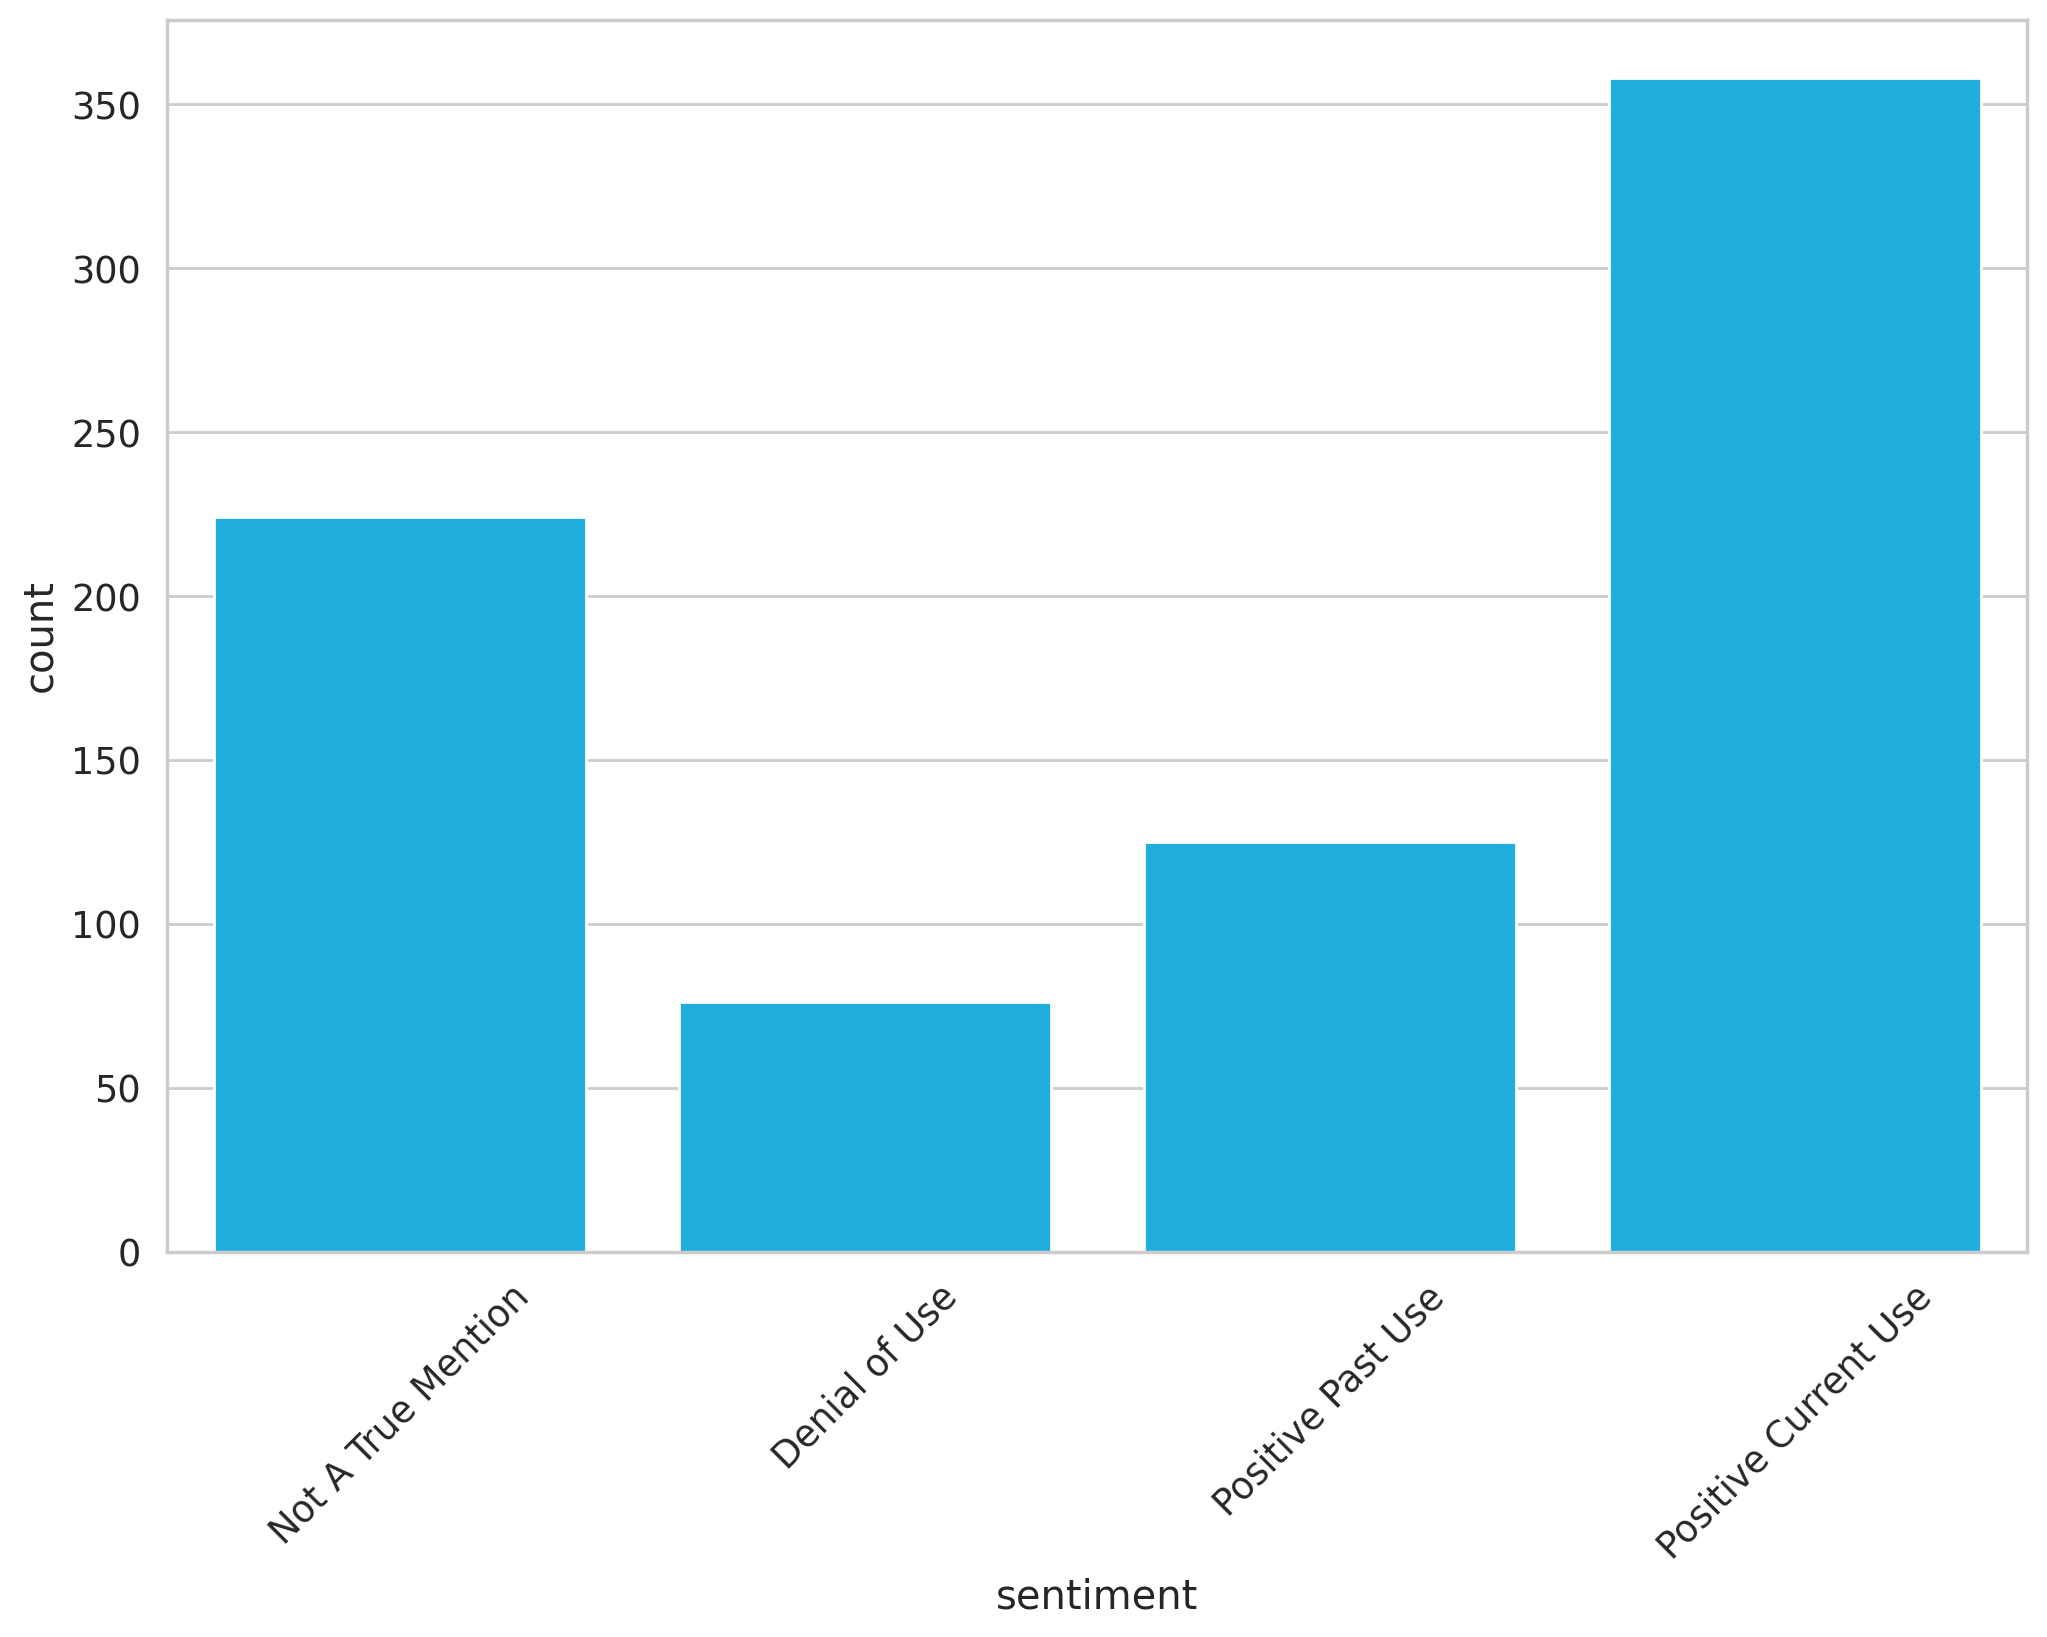

In [18]:

df_train = pd.read_csv("data/set-train_task-status_label-4.csv")
df_train = df_train.rename(columns={"Label": "label"})
df_train['label'] = df_train['label']-1

# distribution of the four class in sentiment
sns.barplot(x=df_train.label.value_counts().index, y=df_train.label.value_counts())
plt.xticks(ticks=range(len(class_label_names)), labels=class_label_names, rotation=45)
plt.xlabel('sentiment')

In [19]:
import optuna
PRE_TRAINED_MODEL_dir='LLMs/gatortron-base'
from transformers import AutoTokenizer, DataCollatorWithPadding
# ——————— Optuna objective ——————————————————————————
def objective(trial: optuna.Trial) -> float:
    dropout = trial.suggest_float("dropout", 0.05, 0.2, step=0.05)
    lr = trial.suggest_float("lr", 5e-5, 1e-3, log=True)
    batch = trial.suggest_categorical("batch", [4, 8])
    tune_mode = trial.suggest_categorical("tune_mode", ["full", 'linear_probe'])  # TO DO : add 'lora' back later
    max_len = trial.suggest_int("max_len", 64, 256, step=32)

    df_train = pd.read_csv("data/set-train_task-status_label-4.csv")
    df_train = df_train[["Snippets", "Label"]]
    df_train = df_train.rename(columns={"Label": "label", "Snippets": "text"})
    df_train['label'] = df_train['label']-1
    
    tokenizer = AutoTokenizer.from_pretrained(PRE_TRAINED_MODEL_dir, local_files_only=True)


    print(
        f"\n🔧  Trial {trial.number:02d} "
        f"dropout={dropout}, lr={lr:.2e}, batch={batch}, tune='{tune_mode}, max_len={max_len}'",
        flush=True,
    )

    if tune_mode == "full":
        model = CannabisClassifier(PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir, 
                                   n_classes=len(np.unique(df_train.label)), 
                                   dropout_rate=dropout)
    elif tune_mode == "linear_probe":
        model = CannabisClassifierFrozenBackbone(PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir,
            n_classes=len(np.unique(df_train.label)),
            dropout_rate=dropout
        )
    else:
        raise ValueError(f"Unknown tune mode: {tune_mode}")
    

    # split the data into train and val in a cross validation manner:
    from sklearn.model_selection import StratifiedShuffleSplit
    skf = StratifiedShuffleSplit(n_splits=2, test_size=0.2, random_state=42)
    for train_idx, val_idx in skf.split(df_train, df_train.label):
        train_df = df_train.iloc[train_idx]
        val_df = df_train.iloc[val_idx]
        # print the size of train and val
        print(f"train size: {len(train_df)}, val size: {len(val_df)}")
        
    tr_loader = create_data_loader(train_df, tokenizer, max_len, batch)
    vl_loader = create_data_loader(val_df, tokenizer, max_len, batch)

    best_val, patience, wait = math.inf, 3, 0
    hist: Dict[str, List[float]] = {
        "tloss": [],
        "vloss": [],
        "tacc": [],
        "vacc": [],
    }
    opt = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    loss_fn=nn.CrossEntropyLoss().to(device)
    max_epochs = 10
    total_steps=len(train_df)*max_epochs
    scheduler=get_linear_schedule_with_warmup(
        opt,
        num_warmup_steps=0,
        num_training_steps=total_steps
    )
    
    for ep in range(1, max_epochs + 1):
        # —— training step ——
        model.train()
        tloss = train_epoch(
                model,
                tr_loader,    
                loss_fn, 
                opt, 
                device, 
                scheduler
            )
        

        # —— AUC on train set ——
        _, tacc = eval_model(
                        model,
                        tr_loader,
                        loss_fn,
                        device
                        )
        

        # —— validation ——
        vloss, vacc = eval_model(
                        model,
                        vl_loader,
                        loss_fn,
                        device
                        )
        
        # —— bookkeeping / logging ——
        hist["tloss"].append(tloss)
        hist["vloss"].append(vloss)
        hist["tacc"].append(tacc)
        hist["vacc"].append(vacc)
        print(
            f"[{trial.number:02d}] Ep {ep:02d}/{max_epochs} "
            f"train‑loss {tloss:.4f} val‑loss {vloss:.4f} "
            f"train‑ACC {tacc:.3f} val‑ACC {vacc:.3f}",
            flush=True,
        )

        trial.report(vloss, ep)
        if trial.should_prune():
            raise optuna.TrialPruned()

        if vloss < best_val:  # early‑stop patience
            best_val, wait, best_state = vloss, 0, model.state_dict()
        else:
            wait += 1
            if wait >= patience:
                break

    # —— save curves for later inspection ——
    tdir = f"output/gatortron-base_finetune_status/trial_{trial.number}/"
    os.makedirs(tdir, exist_ok=True)
    np.save(tdir + "train_loss.npy", np.array(hist["tloss"]))
    np.save(tdir + "val_loss.npy", np.array(hist["vloss"]))
    np.save(tdir + "train_auc.npy", np.array(hist["tacc"]))
    np.save(tdir + "val_auc.npy", np.array(hist["vacc"]))

    def _plot(a1, a2, lab, fn):
        plt.figure()
        plt.plot(a1, label="train")
        plt.plot(a2, label="val")
        plt.xlabel("epoch")
        plt.ylabel(lab)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(tdir + fn)
        plt.close()

    _plot(hist["tloss"], hist["vloss"], "loss", "loss_over_epochs.png")
    _plot(hist["tacc"], hist["vacc"], "ACC", "acc_over_epochs.png")

    trial.set_user_attr("best_state", best_state)
    return best_val



In [20]:
# use Optuna to optimize hyperparameters


num_trials=10
hparam_func = lambda trial: {
    "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
    "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32]),
    "dropout_rate": trial.suggest_float("dropout_rate", 0.1, 0.5),
    "max_len": trial.suggest_int("max_len", 64, 256, step=32),
    "tune_mode": trial.suggest_categorical("tune_mode", ["full", "linear_probe"]),
}

study = optuna.create_study(
        direction="minimize", sampler=optuna.samplers.TPESampler()
    )
study.optimize(objective, n_trials=num_trials)

best = study.best_trial
params = best.params
print("🔎  Best params:", params)

print('Hparam sweep complete!')
print(f"Best trial number: {study.best_trial.number}")
print(f'Best params: {study.best_params}')
print(f'Best loss: {study.best_value:.3f}')




[I 2026-01-06 09:17:22,019] A new study created in memory with name: no-name-c01560f2-34dc-42b5-9cea-9a274d95b8e4



🔧  Trial 00 dropout=0.2, lr=3.98e-04, batch=4, tune='full, max_len=64'
train size: 626, val size: 157
train size: 626, val size: 157
[00] Ep 01/10 train‑loss 1.4135 val‑loss 1.2887 train‑ACC 0.286 val‑ACC 0.287
[00] Ep 02/10 train‑loss 1.3370 val‑loss 1.2960 train‑ACC 0.286 val‑ACC 0.287
[00] Ep 03/10 train‑loss 1.3258 val‑loss 1.1967 train‑ACC 0.417 val‑ACC 0.446
[00] Ep 04/10 train‑loss 1.2957 val‑loss 1.2675 train‑ACC 0.457 val‑ACC 0.459
[00] Ep 05/10 train‑loss 1.3254 val‑loss 1.2318 train‑ACC 0.457 val‑ACC 0.459
[00] Ep 06/10 train‑loss 1.3102 val‑loss 1.2362 train‑ACC 0.457 val‑ACC 0.459


[I 2026-01-06 09:18:13,220] Trial 0 finished with value: 1.1967315167188644 and parameters: {'dropout': 0.2, 'lr': 0.00039751769613983426, 'batch': 4, 'tune_mode': 'full', 'max_len': 64}. Best is trial 0 with value: 1.1967315167188644.



🔧  Trial 01 dropout=0.1, lr=6.33e-04, batch=8, tune='full, max_len=224'
train size: 626, val size: 157
train size: 626, val size: 157
[01] Ep 01/10 train‑loss 1.3887 val‑loss 1.2783 train‑ACC 0.457 val‑ACC 0.459
[01] Ep 02/10 train‑loss 1.2403 val‑loss 1.1207 train‑ACC 0.604 val‑ACC 0.573
[01] Ep 03/10 train‑loss 1.1438 val‑loss 1.1103 train‑ACC 0.610 val‑ACC 0.605
[01] Ep 04/10 train‑loss 1.0463 val‑loss 1.0542 train‑ACC 0.618 val‑ACC 0.580
[01] Ep 05/10 train‑loss 0.9812 val‑loss 0.9652 train‑ACC 0.655 val‑ACC 0.618
[01] Ep 06/10 train‑loss 0.9200 val‑loss 1.0772 train‑ACC 0.712 val‑ACC 0.554
[01] Ep 07/10 train‑loss 0.8506 val‑loss 1.2794 train‑ACC 0.748 val‑ACC 0.567
[01] Ep 08/10 train‑loss 0.8021 val‑loss 1.1316 train‑ACC 0.778 val‑ACC 0.650


[I 2026-01-06 09:19:12,202] Trial 1 finished with value: 0.9652104452252388 and parameters: {'dropout': 0.1, 'lr': 0.0006327371933826778, 'batch': 8, 'tune_mode': 'full', 'max_len': 224}. Best is trial 1 with value: 0.9652104452252388.


...


🔧  Trial 08 dropout=0.05, lr=5.56e-05, batch=4, tune='linear_probe, max_len=128'
train size: 626, val size: 157
train size: 626, val size: 157
[08] Ep 01/10 train‑loss 1.2432 val‑loss 1.1997 train‑ACC 0.458 val‑ACC 0.459
[08] Ep 02/10 train‑loss 1.2088 val‑loss 1.1790 train‑ACC 0.458 val‑ACC 0.459


[I 2026-01-06 09:22:05,747] Trial 8 pruned. 



🔧  Trial 09 dropout=0.1, lr=5.35e-05, batch=8, tune='full, max_len=64'
train size: 626, val size: 157
train size: 626, val size: 157
[09] Ep 01/10 train‑loss 1.0297 val‑loss 0.7969 train‑ACC 0.732 val‑ACC 0.662
[09] Ep 02/10 train‑loss 0.6040 val‑loss 0.5246 train‑ACC 0.904 val‑ACC 0.803
[09] Ep 03/10 train‑loss 0.3974 val‑loss 0.6663 train‑ACC 0.958 val‑ACC 0.834
[09] Ep 04/10 train‑loss 0.4136 val‑loss 0.6937 train‑ACC 0.973 val‑ACC 0.847
[09] Ep 05/10 train‑loss 0.2012 val‑loss 1.1639 train‑ACC 0.970 val‑ACC 0.803


[I 2026-01-06 09:22:33,645] Trial 9 finished with value: 0.5246235098689794 and parameters: {'dropout': 0.1, 'lr': 5.348590795003323e-05, 'batch': 8, 'tune_mode': 'full', 'max_len': 64}. Best is trial 9 with value: 0.5246235098689794.


🔎  Best params: {'dropout': 0.1, 'lr': 5.348590795003323e-05, 'batch': 8, 'tune_mode': 'full', 'max_len': 64}
Hparam sweep complete!
Best trial number: 9
Best params: {'dropout': 0.1, 'lr': 5.348590795003323e-05, 'batch': 8, 'tune_mode': 'full', 'max_len': 64}
Best loss: 0.525


In [ ]:
# — rebuild best model (train + val) —————————————————
if params.get("tune_mode", "full") == "full":
    model = CannabisClassifier(
        PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir,
        n_classes=len(np.unique(df_test.label)),
        dropout_rate=params["dropout"],
    )
else:
    model = CannabisClassifierFrozenBackbone(
        PRE_TRAINED_MODEL_NAME=PRE_TRAINED_MODEL_dir,
        n_classes=len(np.unique(df_test.label)),
        dropout_rate=params["dropout"],
    )


model.load_state_dict(best.user_attrs["best_state"])
model.eval()
loss_fn=nn.CrossEntropyLoss().to(device)
# — final **test** evaluation ————————————————————
test_loader = create_data_loader(df_test, tokenizer, params['max_len'], 1)
test_loss, test_acc = eval_model(
    model,
    test_loader,
    loss_fn,
    device
)

print(f"\n FINAL TEST — ACC={test_acc:.3f} LOSS={test_loss:.3f}")

# save the final best model
tdir = f"output/gatortron-base_finetune_status/best_model/"
os.makedirs(tdir, exist_ok=True)
torch.save(model.state_dict(), tdir + f"best_model_state_tune-{params['tune_mode']}.bin")

# save the params
import json
with open(tdir + f"best_model_params.json", 'w') as f:
    json.dump(params, f, indent=4)

# save the final model
torch.save(model.state_dict(), "output/gatortron-base_finetune_status/FineTunedGatorTron_task-status_final.pth")


🎯  FINAL TEST — ACC=0.900 LOSS=0.495


In [22]:
y_pred, y_pred_probs, y_test = get_predictions(
  model,
  test_loader
)

# save 
tdir = f"output/gatortron-base_finetune_status/"
np.save(os.path.join(tdir, "y_test_best.npy"), y_test.numpy())
np.save(os.path.join(tdir, "y_pred_best.npy"), y_pred.numpy())


In [23]:

print(classification_report(y_test, y_pred, target_names=class_label_names, digits=3))
    

                      precision    recall  f1-score   support

  Not A True Mention      0.889     0.800     0.842        10
       Denial of Use      1.000     0.800     0.889        10
   Positive Past Use      0.833     1.000     0.909        10
Positive Current Use      0.909     1.000     0.952        10

            accuracy                          0.900        40
           macro avg      0.908     0.900     0.898        40
        weighted avg      0.908     0.900     0.898        40

